# hyrax-parsnip workflow demo

This notebook walks through the full workflow of running [ParSNIP](https://parsnip.readthedocs.io)
through [Hyrax](https://hyrax.readthedocs.io) on light curves stored in a
[HATS](https://hats.readthedocs.io) catalog:

1. Build a small HATS catalog of light curves (toy data; swap in your own catalog path).
2. Run **inference with the pretrained `plasticc` ParSNIP model**, with no training needed.
3. Look at the ParSNIP latent space.
4. **Train a LightGBM classifier** on the latents, save it, reload it, and classify objects.
5. *(Optional)* **Fine-tune** ParSNIP with `h.train()`, export it, and run inference again.

Run it with the repo's `.venv` kernel (`hyrax-parsnip (.venv)`). Outputs go to `data/` and
`results/`, which git ignores.

In [1]:
from pathlib import Path

import lsdb
import matplotlib.pyplot as plt
import nested_pandas as npd
import numpy as np
import pandas as pd
from hyrax import Hyrax

import hyrax_parsnip

DATA_DIR = Path("data")
RESULTS_DIR = Path("results") / "demo"
CATALOG_PATH = DATA_DIR / "toy_supernovae"

2026/09/24 12:08:26 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/mi/Work/sn_classification_hyrax/.venv/lib/python3.12/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


## 1. A HATS catalog of light curves

`hyrax-parsnip` expects a **nested** HATS catalog with one row per object:

| column       | type                                   |
|--------------|----------------------------------------|
| `object_id`  | id                                     |
| `redshift`   | float                                  |
| `lightcurve` | nested: `mjd`, `flux`, `fluxerr`, `band` |

All column names are configurable under `[data_set.ParsnipHATSDataset]`.

**If you already have a catalog** (e.g. PLAsTiCC or ELAsTiCC converted to HATS), set `CATALOG_PATH`
to it and skip the next cell. Otherwise we simulate a small one with [sncosmo](https://sncosmo.readthedocs.io)
(installed with ParSNIP): three classes of supernovae (Type Ia, Type II-P and Type Ib/c from the Nugent
templates) at redshift 0.03–0.2, observed in LSST `ugrizy` with a random nightly cadence. Fluxes use the
PLAsTiCC zeropoint (27.5, AB). The first run downloads the templates into the sncosmo cache.

In [2]:
import sncosmo
from astropy.cosmology import Planck18

BANDS = list("ugrizy")
ZP = 27.5  # PLAsTiCC flux zeropoint (AB)
# class -> (sncosmo template, peak absolute B magnitude, scatter)
CLASSES = {
    "SNIa": ("nugent-sn1a", -19.3, 0.15),
    "SNII": ("nugent-sn2p", -16.8, 0.5),
    "SNIbc": ("nugent-sn1bc", -17.5, 0.4),
}


def simulate_catalog(n_per_class=100, n_obs=100, seed=0):
    rng = np.random.default_rng(seed)
    objects, observations = [], []
    for label, (source, absmag, scatter) in CLASSES.items():
        model = sncosmo.Model(source)
        for _ in range(n_per_class):
            i = len(objects)
            z = rng.uniform(0.03, 0.2)
            model.set(z=z, t0=60100 + rng.uniform(-20, 20))
            model.set_source_peakabsmag(absmag + rng.normal(0, scatter), "bessellb", "ab", cosmo=Planck18)

            # Roughly nightly cadence over 250 days with sub-day offsets, one band per visit.
            mjd = np.sort(60000 + rng.choice(250, n_obs, replace=False) + rng.uniform(0.1, 0.3, n_obs))
            band = rng.choice(BANDS, n_obs)
            true_flux = model.bandflux(["lsst" + b for b in band], mjd, zp=ZP, zpsys="ab")
            fluxerr = np.sqrt(20.0**2 + np.abs(true_flux))  # sky + source noise
            flux = true_flux + rng.normal(0, fluxerr)

            objects.append({
                "object_id": f"sn{i:04d}",
                "ra": rng.uniform(0, 360),
                "dec": rng.uniform(-60, 20),
                "redshift": z,
                "type": label,
            })
            observations.append(pd.DataFrame(
                {"mjd": mjd, "flux": flux, "fluxerr": fluxerr, "band": band},
                index=np.full(n_obs, i),
            ))

    nested = npd.NestedFrame(pd.DataFrame(objects)).join_nested(pd.concat(observations), "lightcurve")
    return lsdb.from_dataframe(nested, ra_column="ra", dec_column="dec", catalog_name="toy_supernovae")


simulate_catalog().write_catalog(CATALOG_PATH, overwrite=True)
CATALOG_PATH

Writing Catalog:   0%|          | 0/24 [00:00<?, ?it/s]

PosixPath('data/toy_supernovae')

Open the catalog with LSDB to check what it looks like:

In [3]:
catalog = lsdb.open_catalog(CATALOG_PATH)
frame = catalog.compute()
print(f"{len(frame)} objects, columns: {list(frame.columns)}")
frame[["object_id", "redshift", "type", "lightcurve"]].head()

Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

300 objects, columns: ['object_id', 'ra', 'dec', 'redshift', 'type', 'lightcurve']


object_id  redshift  type  \
_healpix_29                                    
15304055382957065     sn0120  0.090977  SNII   
294063847338689992    sn0002  0.192577  SNIa   
300312497732809538    sn0054  0.193913  SNIa   
304285561044687125    sn0128   0.08634  SNII   
331181167943655134    sn0131  0.069488  SNII   

                                                           lightcurve  
_healpix_29                                                            
15304055382957065   [{mjd: 60005.279036, flux: 23.330177, fluxerr:...  
294063847338689992  [{mjd: 60007.264062, flux: 35.101832, fluxerr:...  
300312497732809538  [{mjd: 60001.21886, flux: 20.898909, fluxerr: ...  
304285561044687125  [{mjd: 60004.159948, flux: -0.20526, fluxerr: ...  
331181167943655134  [{mjd: 60002.225507, flux: 17.194258, fluxerr:...

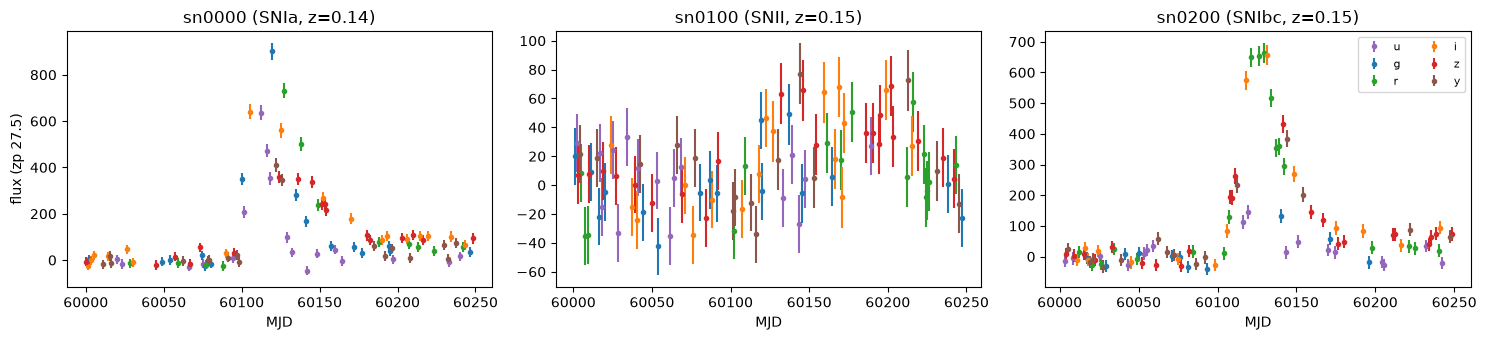

In [4]:
BAND_COLORS = dict(zip(BANDS, ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red", "tab:brown"]))


def plot_lightcurve(ax, row, title=None):
    lc = row["lightcurve"]
    for band in BANDS:
        sel = lc[lc["band"] == band]
        ax.errorbar(sel["mjd"], sel["flux"], sel["fluxerr"], fmt="o", ms=3, color=BAND_COLORS[band], label=band)
    ax.set_title(title or f"{row['object_id']} ({row['type']}, z={row['redshift']:.2f})")
    ax.set_xlabel("MJD")


examples = pd.concat([frame[frame["type"] == c].sort_values("object_id").head(1) for c in CLASSES])
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, (_, row) in zip(axes, examples.iterrows()):
    plot_lightcurve(ax, row)
axes[0].set_ylabel("flux (zp 27.5)")
axes[-1].legend(ncol=2, fontsize=8)
plt.tight_layout()

## 2. Inference with a pretrained ParSNIP model

`hyrax_parsnip.configure` points a Hyrax instance at the catalog and the ParSNIP model. With
`pretrained="plasticc"` it also sets `infer.model_weights_file` to ParSNIP's built-in PLAsTiCC
model, so `h.infer()` runs right away without a training run.

The default `band_map` maps catalog bands `ugrizy` to `lsstu`…`lssty`, the bands the `plasticc`
model knows. For another survey, set `data_set.ParsnipHATSDataset.band_map` (globally, not per data request).

In [5]:
h = Hyrax()
h.set_config("general.results_dir", str(RESULTS_DIR))
h.set_config("data_loader.batch_size", 64)
hyrax_parsnip.configure(h, CATALOG_PATH, pretrained="plasticc")

h.config["data_set"]["ParsnipHATSDataset"]["band_map"]

[2026-09-24 12:08:33,332 hyrax.config_utils:INFO] Merging external default config from /Users/mi/Work/sn_classification_hyrax/src/hyrax_parsnip/default_config.toml


[2026-09-24 12:08:33,353 hyrax.config_utils:INFO] Merging external default config from /Users/mi/Work/sn_classification_hyrax/src/hyrax_parsnip/default_config.toml


[2026-09-24 12:08:33,376 hyrax.config_utils:INFO] Merging external default config from /Users/mi/Work/sn_classification_hyrax/src/hyrax_parsnip/default_config.toml


[2026-09-24 12:08:34,367 hyrax.config_utils:INFO] Merging external default config from /Users/mi/Work/sn_classification_hyrax/src/hyrax_parsnip/default_config.toml


{'u': 'lsstu', 'g': 'lsstg', 'r': 'lsstr', 'i': 'lssti', 'z': 'lsstz', 'y': 'lssty'}

In [6]:
results = h.infer()

Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

/Users/mi/Work/sn_classification_hyrax/.venv/lib/python3.12/site-packages/parsnip/parsnip.py:297: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:255.)
  self.band_interpolate_weights = torch.FloatTensor(band_weights).to(self.device)


[2026-09-24 12:08:34,577 hyrax.models.model_registry:WARNING] Both model and config define an optimizer. Hyrax will use self.optimizer defined in the model.


[2026-09-24 12:08:34,577 hyrax.models.model_registry:INFO] Using self.optimizer defined in model: torch.optim.adam.Adam


[2026-09-24 12:08:34,577 hyrax.models.model_registry:WARNING] Both model and config define a criterion. Hyrax will use self.criterion defined in the model.


...

 20%|##        | 1/5 [00:00<?, ?it/s]

[2026-09-24 12:08:49,228 hyrax.pytorch_ignite:INFO] Total evaluation time: 14.59[s]


[2026-09-24 12:08:49,228 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 5 batches


[2026-09-24 12:08:49,238 hyrax.datasets.result_dataset:INFO] Lance table optimization complete


[2026-09-24 12:08:49,239 hyrax.verbs.infer:INFO] Inference Complete.


`load_predictions` turns Hyrax's results into a ParSNIP-style astropy table (one row per object),
and can join extra catalog columns such as the class label. Objects ParSNIP can't process get NaN
features instead of being dropped, so ids stay aligned.

In [7]:
labels = hyrax_parsnip.catalog_metadata(CATALOG_PATH, ["type"])
predictions = hyrax_parsnip.load_predictions(results, metadata=labels)

print(f"{len(predictions)} objects, {len(predictions.colnames)} columns")
predictions["object_id", "type", "s1", "s2", "s3", "color", "amplitude", "luminosity", "reference_time"][:5]

Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

300 objects, 27 columns


object_id,type,s1,s2,s3,color,amplitude,luminosity,reference_time
str6,str5,float64,float64,float64,float64,float64,float64,float64
sn0000,SNIa,0.2445317804813385,-0.5021212697029114,-0.06078031659126282,-0.0867215171456337,7.357261657714844,-16.31145490467702,60115.36421553598
sn0001,SNIa,0.10676035284996033,-1.1400392055511475,-0.10743403434753418,-0.1556466668844223,19.048412322998047,-16.294390266740734,60112.25205230135
sn0002,SNIa,0.9089242219924927,-0.3215000033378601,-0.04080526530742645,0.03305968642234802,5.940376281738281,-16.869605444870857,60133.057463685705
sn0003,SNIa,0.6976008415222168,-0.5674481987953186,0.46123582124710083,-0.034401483833789825,12.957088470458984,-16.34075202456387,60107.70201128111
sn0004,SNIa,0.8087807893753052,-0.4031698703765869,0.337571918964386,-0.02233913540840149,23.74900245666504,-16.524134892264883,60139.826594422135


## 3. The ParSNIP latent space

ParSNIP describes each light curve with intrinsic latents `s1..s3`, plus a color, an amplitude and
a reference time. The three supernova classes land in different parts of the latent space:

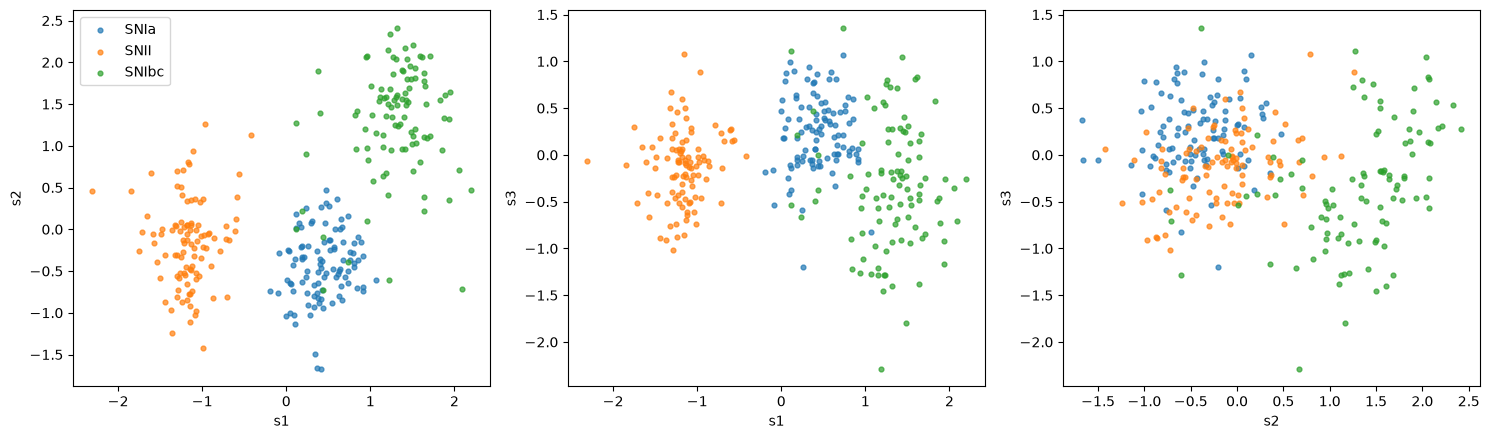

In [8]:
types = np.asarray(predictions["type"])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (x, y) in zip(axes, [("s1", "s2"), ("s1", "s3"), ("s2", "s3")]):
    for label, color in zip(CLASSES, ["tab:blue", "tab:orange", "tab:green"]):
        sel = types == label
        ax.scatter(predictions[x][sel], predictions[y][sel], s=12, alpha=0.7, color=color, label=label)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
axes[0].legend()
plt.tight_layout()

## 4. Classification

ParSNIP doesn't ship a pretrained classifier. `train_classifier` trains ParSNIP's LightGBM
classifier on the labeled predictions with K-fold cross-validation and returns out-of-sample
probabilities for every training object, which give a fair estimate of accuracy.

ParSNIP's default LightGBM `min_child_weight=1000` is tuned for PLAsTiCC-sized training sets (thousands
of objects per class). On a few hundred objects it prevents any split and every probability comes out
equal, so we lower it here. On a large training set, keep the default.

In [9]:
classifier, out_of_sample = hyrax_parsnip.train_classifier(
    predictions, label_column="type", num_folds=5, min_child_weight=10.0
)

from astropy.table import join

class_names = [str(c) for c in classifier.class_names]
oos = join(out_of_sample, predictions["object_id", "type"], keys="object_id")
oos_probs = np.stack([np.asarray(oos[c]) for c in class_names], axis=1)
oos_pred = np.asarray(class_names)[oos_probs.argmax(axis=1)]
oos_true = np.asarray(oos["type"])

print(f"Out-of-sample accuracy: {np.mean(oos_pred == oos_true):.3f}")
pd.crosstab(pd.Series(oos_true, name="true"), pd.Series(oos_pred, name="predicted"))

Training classifier with keys:
    color
    color_error
    s1
    s1_error
    s2
    s2_error
    s3
    s3_error
    luminosity
    luminosity_error
    reference_time_error


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000039 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 895
[LightGBM] [Info] Number of data points in the train set: 240, number of used features: 11
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

/Users/mi/Work/sn_classification_hyrax/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/mi/Work/sn_classification_hyrax/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/mi/Work/sn_classification_hyrax/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/mi/Work/sn_classification_hyrax/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is dep

predicted,SNII,SNIa,SNIbc
true,,,
SNII,100,0,0
SNIa,0,100,0
SNIbc,0,1,99


Accuracy is this high because each class comes from a single template. Real data (e.g. PLAsTiCC)
is much harder. The point here is the workflow.

Save the classifier and reload it later to classify **new** inference results without retraining.
Here we reload it and apply it to the same predictions to show the round trip.

In [10]:
classifier_path = RESULTS_DIR / "parsnip_classifier.pkl"
classifier.write(str(classifier_path.resolve()))

reloaded = hyrax_parsnip.load_classifier(classifier_path)
probabilities = hyrax_parsnip.classify(reloaded, predictions)
probabilities[:5]

object_id,SNII,SNIa,SNIbc
str6,float64,float64,float64
sn0000,0.02564808861065313,0.9455640916427142,0.028787819746632838
sn0001,0.02844699647214758,0.9405717021142322,0.030981301413620117
sn0002,0.18666678536016298,0.5617216743848623,0.25161154025497473
sn0003,0.02912832640771985,0.9382902421270112,0.03258143146526886
sn0004,0.050302529069693194,0.8927000405249995,0.05699743040530728


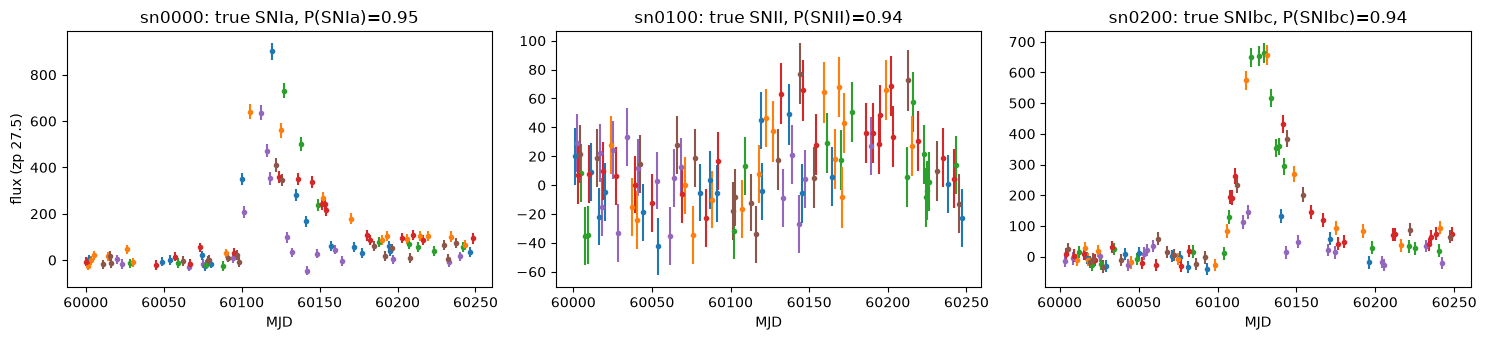

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
probs_by_id = {row["object_id"]: row for row in probabilities}
for ax, (_, row) in zip(axes, examples.iterrows()):
    p = probs_by_id[row["object_id"]]
    best = max(class_names, key=lambda c: p[c])
    plot_lightcurve(ax, row, title=f"{row['object_id']}: true {row['type']}, P({best})={p[best]:.2f}")
axes[0].set_ylabel("flux (zp 27.5)")
plt.tight_layout()

## 5. *(Optional)* Fine-tune ParSNIP with Hyrax

Training is optional. `h.train()` uses ParSNIP's own loss, optimizer, augmentation and learning-rate
schedule. Pass `pretrained=False` to train from scratch, or a model name to fine-tune it.
`model_weights_file=False` makes the next `h.infer()` use the weights from this training run.

A Hyrax epoch is one pass over the catalog. ParSNIP's own `fit` counts about 25,000 augmented light curves as
an epoch, so on a real catalog you'd use far more epochs than the few we run here.

In [12]:
h_train = Hyrax()
h_train.set_config("general.results_dir", str(RESULTS_DIR))
h_train.set_config("data_loader.batch_size", 64)
h_train.set_config("train.epochs", 3)
hyrax_parsnip.configure(
    h_train, CATALOG_PATH, pretrained="plasticc", groups=("train", "infer"), model_weights_file=False
)

model = h_train.train()
model.final_training_metrics

[2026-09-24 12:08:49,904 hyrax.config_utils:INFO] Merging external default config from /Users/mi/Work/sn_classification_hyrax/src/hyrax_parsnip/default_config.toml


[2026-09-24 12:08:49,925 hyrax.config_utils:INFO] Merging external default config from /Users/mi/Work/sn_classification_hyrax/src/hyrax_parsnip/default_config.toml


[2026-09-24 12:08:49,948 hyrax.config_utils:INFO] Merging external default config from /Users/mi/Work/sn_classification_hyrax/src/hyrax_parsnip/default_config.toml


[2026-09-24 12:08:49,971 hyrax.config_utils:INFO] Merging external default config from /Users/mi/Work/sn_classification_hyrax/src/hyrax_parsnip/default_config.toml


Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

...

[2026-09-24 12:09:41,757 hyrax.pytorch_ignite:INFO] Total training time: 50.36[s]


2026/09/24 12:09:41 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


2026/09/24 12:09:41 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


[2026-09-24 12:09:41,778 hyrax.verbs.train:INFO] Finished Training


{'loss': 79.47211803089489}

Export the fine-tuned model in ParSNIP's native `.pt` format. It then works with `parsnip.load_model` or `configure(..., pretrained="path.pt")`:

In [13]:
export_path = RESULTS_DIR / "parsnip_finetuned.pt"
model.export_parsnip(export_path)

finetuned = hyrax_parsnip.load_predictions(h_train.infer(), metadata=labels)
finetuned["object_id", "type", "s1", "s2", "s3", "color", "luminosity"][:5]

Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

[2026-09-24 12:09:41,975 hyrax.models.model_registry:WARNING] Both model and config define an optimizer. Hyrax will use self.optimizer defined in the model.


[2026-09-24 12:09:41,975 hyrax.models.model_registry:INFO] Using self.optimizer defined in model: torch.optim.adam.Adam


[2026-09-24 12:09:41,975 hyrax.models.model_registry:WARNING] Both model and config define a criterion. Hyrax will use self.criterion defined in the model.


[2026-09-24 12:09:41,975 hyrax.models.model_registry:INFO] Using self.criterion defined in model: builtins.method


...

[2026-09-24 12:09:56,621 hyrax.pytorch_ignite:INFO] Total evaluation time: 14.61[s]


[2026-09-24 12:09:56,622 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 5 batches


[2026-09-24 12:09:56,629 hyrax.datasets.result_dataset:INFO] Lance table optimization complete


[2026-09-24 12:09:56,630 hyrax.verbs.infer:INFO] Inference Complete.


object_id,type,s1,s2,s3,color,luminosity
str6,str5,float64,float64,float64,float64,float64
sn0000,SNIa,0.26913896203041077,-0.34800010919570923,0.0877203494310379,-0.11311373114585876,-16.235244882704364
sn0001,SNIa,0.3445639908313751,-0.9976010918617249,-0.21256856620311737,-0.16397063434123993,-16.283684318864758
sn0002,SNIa,0.6976006031036377,-0.009961962699890137,0.1430332213640213,0.027877621352672577,-16.812009238205817
sn0003,SNIa,0.7623468637466431,-0.06338168680667877,0.33983272314071655,-0.03777763992547989,-16.326275248440822
sn0004,SNIa,0.7290862798690796,0.02502429485321045,0.41575324535369873,-0.005876362789422274,-16.55338980559496


## Next steps

- Point `CATALOG_PATH` at a real HATS catalog (PLAsTiCC / ELAsTiCC), and set the column names and `band_map`
  under `[data_set.ParsnipHATSDataset]` if they differ from the defaults.
- Train the classifier once on a large labeled set, save it, and reuse it with `load_classifier` + `classify`.
- See the `README.md` for macOS notes (CPU device, single-threaded LightGBM) and known limitations.